In [ ]:
!pip install yfinance pandas

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^SSE']: YFPricesMissingError('possibly delisted; no price data found  (1d 2023-01-01 -> 2025-02-18)')


       SPY_return  NIKKEI_return  HANG_SENG_return  SHANGHAI_return
count  531.000000     474.000000        476.000000              0.0
mean     0.000972       0.000625          0.000167              NaN
std      0.008060       0.013639          0.014934              NaN
min     -0.029803      -0.123958         -0.094070              NaN
25%     -0.003234      -0.005685         -0.009726              NaN
50%      0.000990       0.000927         -0.000345              NaN
75%      0.006018       0.007958          0.008853              NaN
max      0.024866       0.102263          0.042140              NaN


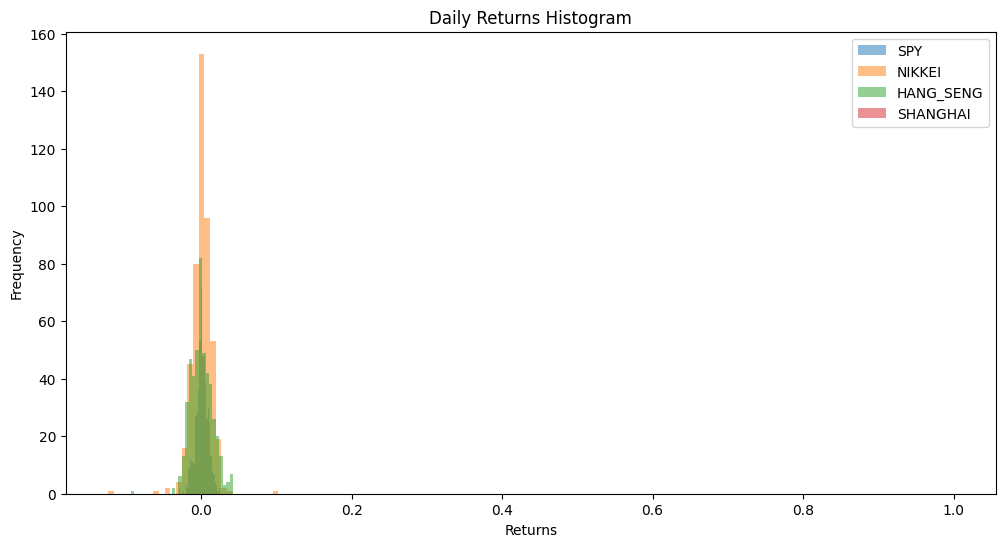

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 定义要获取的指数的股票代码
tickers = {
    'SPY': 'SPY',
    'NIKKEI': '^N225',  # 日经225
    'HANG_SENG': '^HSI',  # 恒生指数
    'SHANGHAI': '^SSE'  # 上证指数
}

# 定义日期范围
start_date = '2023-01-01'
end_date = '2025-02-18'

# 创建一个空的DataFrame来存储数据
data = pd.DataFrame()

# 循环获取每个指数的数据
for name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date)
    data[name] = df['Close']

# 计算日收益率
returns = (data.shift(-1) - data) / data  # 计算收益率
returns = returns.rename(columns=lambda x: f"{x}_return")  # 重命名列以标识为收益率

# 将收益率添加到原始数据集中
combined_data = pd.concat([data, returns], axis=1)

# 删除缺失值
#combined_data = combined_data.dropna()

# 检查收益率数据
print(combined_data[[f"{name}_return" for name in tickers.keys()]].describe())

# 设置图形大小
plt.figure(figsize=(12, 6))

# 绘制每个指数的收益率直方图
for name in tickers.keys():
    plt.hist(combined_data[f"{name}_return"].dropna(), bins=30, alpha=0.5, label=name)

# 添加标题和标签
plt.title('Daily Returns Histogram')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend(loc='upper right')

# 显示图形
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


       SPY_return  NIKKEI_return
count  531.000000     474.000000
mean     0.000972       0.000625
std      0.008060       0.013639
min     -0.029803      -0.123958
25%     -0.003234      -0.005685
50%      0.000990       0.000927
75%      0.006018       0.007958
max      0.024866       0.102263


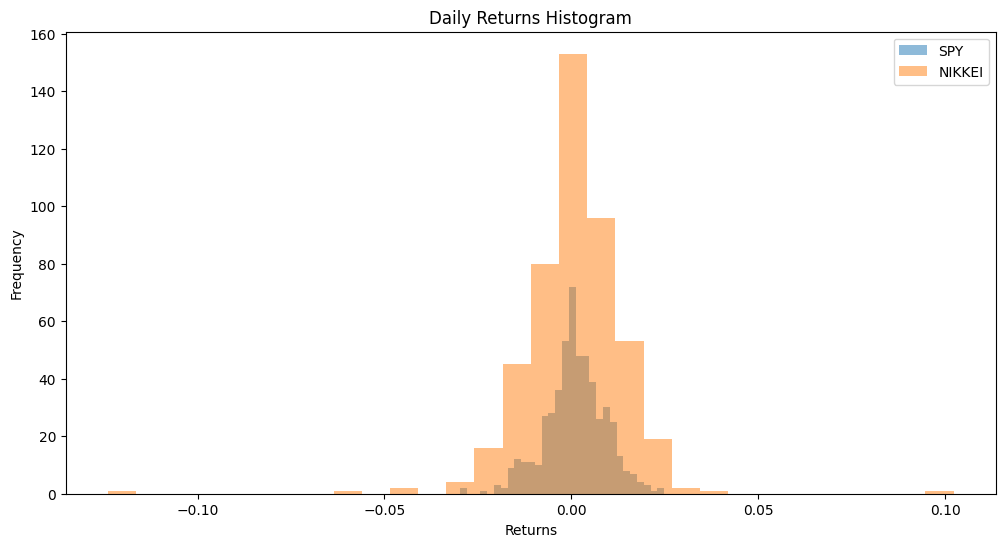

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 定义要获取的指数的股票代码
tickers = {
    'SPY': 'SPY',
    'NIKKEI': '^N225'  # 日经225
}

# 定义日期范围
start_date = '2023-01-01'
end_date = '2025-02-18'

# 创建一个空的DataFrame来存储数据
data = pd.DataFrame()

# 循环获取每个指数的数据
for name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date)
    data[name] = df['Close']

# 计算日收益率
returns = (data.shift(-1) - data) / data  # 计算收益率
returns = returns.rename(columns=lambda x: f"{x}_return")  # 重命名列以标识为收益率

# 将收益率添加到原始数据集中
combined_data = pd.concat([data, returns], axis=1)

# 检查收益率数据
print(combined_data[[f"{name}_return" for name in tickers.keys()]].describe())

# 设置图形大小
plt.figure(figsize=(12, 6))

# 绘制每个指数的收益率直方图
for name in tickers.keys():
    plt.hist(combined_data[f"{name}_return"], bins=30, alpha=0.5, label=name)

# 添加标题和标签
plt.title('Daily Returns Histogram')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend(loc='upper right')

# 显示图形
plt.show()

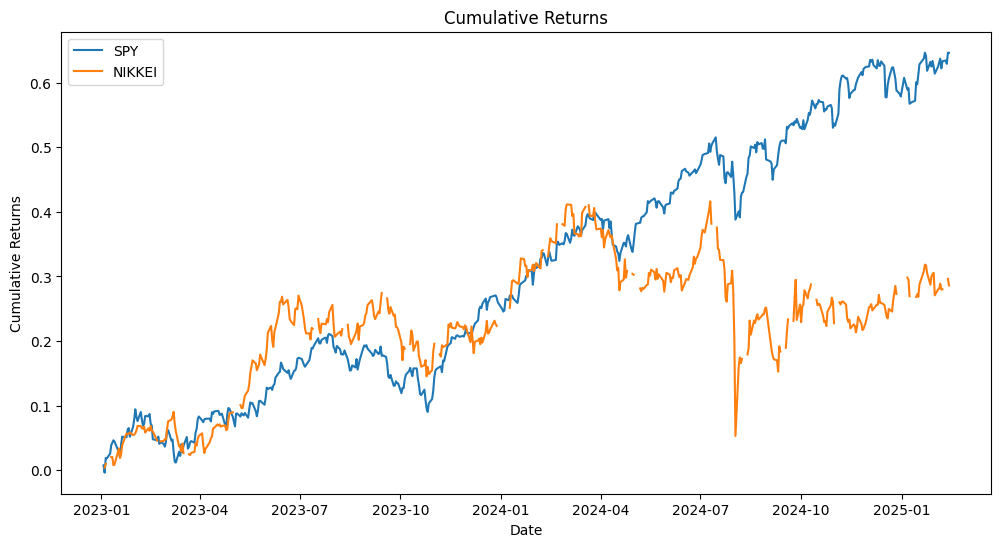

In [ ]:
# 计算累积收益
cumulative_returns = (1 + returns).cumprod() - 1

# 绘制累积收益的折线图
plt.figure(figsize=(12, 6))
for name in tickers.keys():
    plt.plot(cumulative_returns[f"{name}_return"], label=name)

# 添加标题和标签
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend(loc='upper left')

# 显示图形
plt.show()

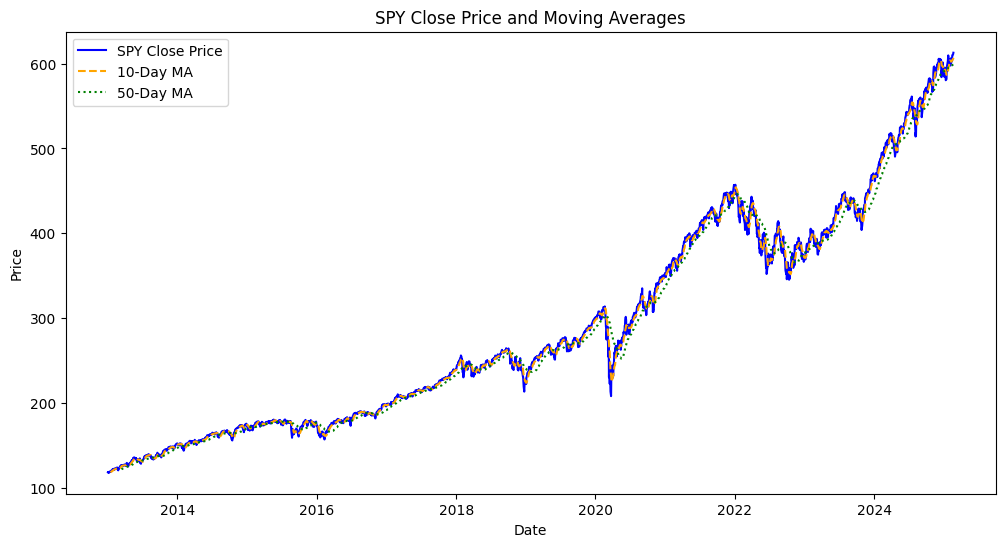

In [ ]:
# 计算 10 天和 50 天移动平均线基于收盘价
moving_average_10 = data['SPY'].rolling(window=10).mean()
moving_average_50 = data['SPY'].rolling(window=50).mean()

# 将均线添加到原始数据集中
data['MA10'] = moving_average_10
data['MA50'] = moving_average_50

# 绘制收盘价及其均线
plt.figure(figsize=(12, 6))
plt.plot(data['SPY'], label='SPY Close Price', color='blue')
plt.plot(data['MA10'], label='10-Day MA', linestyle='--', color='orange')
plt.plot(data['MA50'], label='50-Day MA', linestyle=':', color='green')

# 添加标题和标签
plt.title('SPY Close Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')

# 显示图形
plt.show()

In [ ]:
# 计算日收益率
returns = data['SPY'].shift(-1) / data['SPY'] - 1

# 初始化收益率列
data['10Day_Returns'] = 0.0

# 策略：当10天均线大于50天均线时，收益为下一交易日收益率
data.loc[moving_average_10 > moving_average_50, '10Day_Returns'] = returns

# 检查结果
print(data[['SPY', 'MA10', 'MA50', '10Day_Returns']].tail())

                   SPY        MA10        MA50  10Day_Returns
Date                                                         
2025-02-12  603.359985  603.123999  598.138384       0.010558
2025-02-13  609.729980  603.592999  598.322407      -0.000049
2025-02-14  609.700012  604.381000  598.484303       0.002936
2025-02-18  611.489990  605.752997  598.676418       0.002355
2025-02-19  612.929993  606.867993  598.822585            NaN


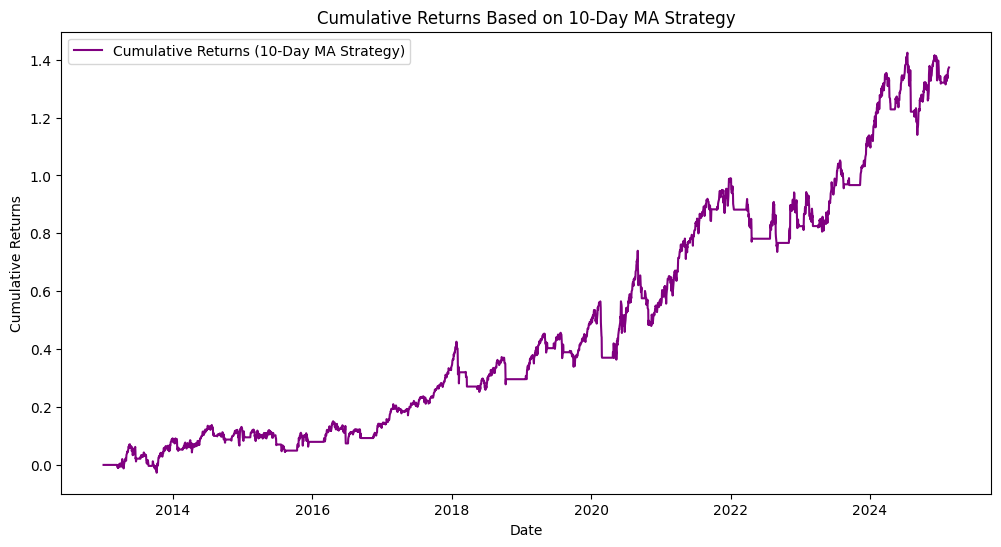

In [ ]:
# 计算累积收益率
data['Cumulative_Returns'] = (1 + data['10Day_Returns']).cumprod() - 1

# 绘制累积收益率的折线图
plt.figure(figsize=(12, 6))
plt.plot(data['Cumulative_Returns'], label='Cumulative Returns (10-Day MA Strategy)', color='purple')

# 添加标题和标签
plt.title('Cumulative Returns Based on 10-Day MA Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend(loc='upper left')

# 显示图形
plt.show()

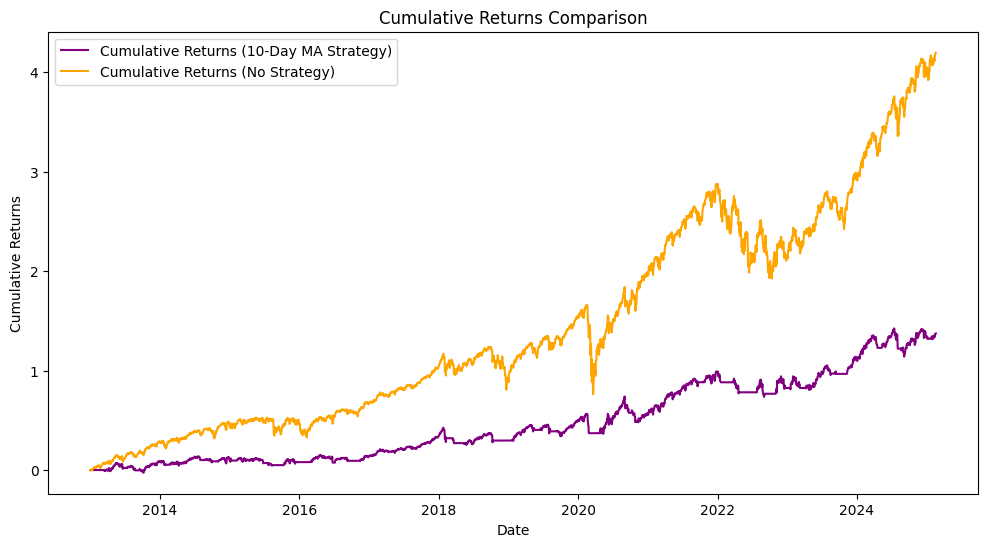

In [ ]:
# 计算没有交易策略的日收益率
data['No_Strategy_Returns'] = data['SPY'].shift(-1) / data['SPY'] - 1

# 计算累积收益率
data['Cumulative_No_Strategy_Returns'] = (1 + data['No_Strategy_Returns']).cumprod() - 1

# 计算基于10天均线的累积收益率
data['Cumulative_Returns'] = (1 + data['10Day_Returns']).cumprod() - 1

# 绘制累积收益率的折线图
plt.figure(figsize=(12, 6))
plt.plot(data['Cumulative_Returns'], label='Cumulative Returns (10-Day MA Strategy)', color='purple')
plt.plot(data['Cumulative_No_Strategy_Returns'], label='Cumulative Returns (No Strategy)', color='orange')

# 添加标题和标签
plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend(loc='upper left')

# 显示图形
plt.show()

In [ ]:
import scipy.stats as stats

# 筛选出有效的收益率
strategy_returns = data['10Day_Returns'].dropna()
no_strategy_returns = data['No_Strategy_Returns'].dropna()

# 进行独立样本 t 检验
t_stat, p_value = stats.ttest_ind(strategy_returns, no_strategy_returns, equal_var=False)

# 输出结果
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# 检验显著性
alpha = 0.05  # 显著性水平
if p_value < alpha:
    print("Reject the null hypothesis: The 10-day strategy returns are significantly higher than no strategy returns.")
else:
    print("Fail to reject the null hypothesis: No significant difference in returns.")

T-statistic: -1.2773156389841231
P-value: 0.201547595031645
Fail to reject the null hypothesis: No significant difference in returns.


In [ ]:
import pandas as pd
import yfinance as yf

# 设置日期范围
start_date = '2013-01-01'
end_date = '2025-01-30'

# 导入数据
spy_data = yf.download('SPY', start=start_date, end=end_date)
nikkei_data = yf.download('^N225', start=start_date, end=end_date)
hang_seng_data = yf.download('^HSI', start=start_date, end=end_date)

# 计算收益率（比例）
spy_data['Daily_Return'] = (spy_data['Close'].shift(-1) - spy_data['Close']) / spy_data['Close']
nikkei_data['Daily_Return'] = (nikkei_data['Close'].shift(-1) - nikkei_data['Close']) / nikkei_data['Close']
hang_seng_data['Daily_Return'] = (hang_seng_data['Close'].shift(-1) - hang_seng_data['Close']) / hang_seng_data['Close']

# 查看结果
print(spy_data[['Close', 'Daily_Return']].tail())
print(nikkei_data[['Close', 'Daily_Return']].tail())
print(hang_seng_data[['Close', 'Daily_Return']].tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price            Close Daily_Return
Ticker             SPY             
Date                               
2025-01-23  609.750000    -0.002919
2025-01-24  607.969971    -0.014145
2025-01-27  599.369995     0.008592
2025-01-28  604.520020    -0.004483
2025-01-29  601.809998          NaN
Price              Close Daily_Return
Ticker             ^N225             
Date                                 
2025-01-23  39958.871094    -0.000673
2025-01-24  39931.980469    -0.009170
2025-01-27  39565.800781    -0.013874
2025-01-28  39016.871094     0.010198
2025-01-29  39414.781250          NaN
Price              Close Daily_Return
Ticker              ^HSI             
Date                                 
2025-01-22  19778.769531    -0.003954
2025-01-23  19700.560547     0.018559
2025-01-24  20066.189453     0.006557
2025-01-27  20197.769531     0.001354
2025-01-28  20225.109375          NaN


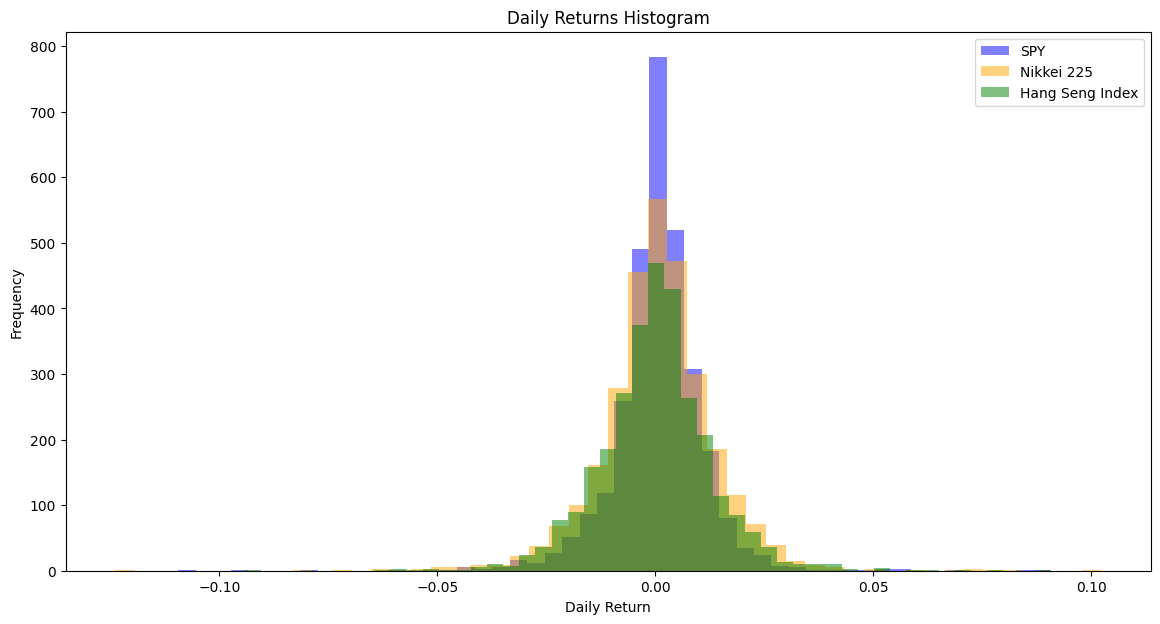

In [ ]:
import matplotlib.pyplot as plt
#plt.style.use('seaborn-darkgrid')
# 绘制直方图
plt.figure(figsize=(14, 7))

# 绘制 SPY 收益率直方图
plt.hist(spy_data['Daily_Return'].dropna(), bins=50, alpha=0.5, label='SPY', color='blue')

# 绘制日经225 收益率直方图
plt.hist(nikkei_data['Daily_Return'].dropna(), bins=50, alpha=0.5, label='Nikkei 225', color='orange')

# 绘制恒生指数 收益率直方图
plt.hist(hang_seng_data['Daily_Return'].dropna(), bins=50, alpha=0.5, label='Hang Seng Index', color='green')

# 添加标签和标题
plt.title('Daily Returns Histogram')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()

# 显示图形
plt.show()

In [ ]:
from scipy import stats

In [ ]:
# 进行 T 检验
# SPY vs Nikkei 225
t_stat_nikkei, p_value_nikkei = stats.ttest_ind(spy_data['Daily_Return'].dropna(),
                                                 nikkei_data['Daily_Return'].dropna(),
                                                 alternative='greater')

# SPY vs Hang Seng Index
t_stat_hang_seng, p_value_hang_seng = stats.ttest_ind(spy_data['Daily_Return'].dropna(),
                                                       hang_seng_data['Daily_Return'].dropna(),
                                                       alternative='greater')

# 输出结果
print(f"SPY vs Nikkei 225: T-statistic = {t_stat_nikkei:.4f}, P-value = {p_value_nikkei:.4f}")
print(f"SPY vs Hang Seng Index: T-statistic = {t_stat_hang_seng:.4f}, P-value = {p_value_hang_seng:.4f}")

SPY vs Nikkei 225: T-statistic = 0.1952, P-value = 0.4226
SPY vs Hang Seng Index: T-statistic = 1.8189, P-value = 0.0345
